# Desafio 1 - Predição de Renda

Pós-graduação em Machine Learning - Desafio Final
Aluno(a): _preencher_

Objetivo: estimar a **renda mensal** do cliente a partir dos dados cadastrais e
comportamentais, usando regressão linear.

### Observação sobre o dataset

O `clientes.csv` disponibilizado tem 1000 clientes e 26 colunas, com nomes diferentes dos
citados na tabela do enunciado. Fiz o de-para abaixo e mantive a lógica pedida em cada etapa:

| Enunciado | Coluna no arquivo |
|---|---|
| `Tempo_Emprego` | `Tempo na Empresa` |
| `Dependentes` | `Pessoas em Casa` |
| `Score_Credito` | `Score` |
| `Estado_Civil` | `Estado Civil` |
| `Escolaridade` | não existe (uso `Cargo`, `Cidade` e `Moradia` como cadastrais) |
| `Gasto_Mensal_Cartao` | não existe (o arquivo traz notas de preferência de consumo de 1 a 5) |

A target `Renda` existe normalmente, então o desafio em si não muda.

Roteiro:
1. Carga e exploração
2. Análise estatística (correlação e ANOVA)
3. Pré-processamento
4. Modelo simples x modelo com termos polinomiais
5. Avaliação (RMSE, MAE, R², validação cruzada e resíduos)
6. Conclusões

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from scipy.stats import f_oneway
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import OneHotEncoder, PolynomialFeatures
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42  # deixo fixo para o resultado não mudar a cada execução

## 1. Carga e exploração inicial

In [2]:
df = pd.read_csv("datasets/clientes.csv")
print("Shape:", df.shape)
df.head()

Shape: (1000, 26)


,ID_Cliente,Nome,Idade,Viagens,Restaurantes,Entretenimento,Cashback,Compras online,Farmácias,Programas de Milhagem,...,Pessoas em Casa,Moradia,Possui Carro,Renda,Investimentos,Ativos,Dívidas,Probabilidade Inadimplencia,Score,Principal Cartão
0,bc3749c2-932f-462b-a71e-d1a352510f67,Nicole Lopes,32,5,4,2,4,5,3,1,...,2,Próprio,True,34118,631262,55649,294254,0.00,232,Rocketseat Mastercard Travel Elite
1,981dffc4-087e-4a99-bbac-062944f9b5a7,Kevin Teixeira,42,1,4,5,1,4,1,5,...,2,Alugado,True,7338,376417,1777324,180331,87.00,27,Rocketseat Mastercard Life Basic
2,242f4e94-7f2a-4557-a27a-9227cca55e83,Augusto Sá,67,4,3,4,3,2,3,3,...,6,Alugado,True,19965,83667,1793731,122049,78.45,57,Rocketseat Mastercard Travel Basic
3,e6f16b89-d9bf-4448-9d08-65957cdc1fb3,Ágatha Moura,47,2,3,1,2,1,3,4,...,6,Próprio,False,25867,283060,1940685,335544,85.21,32,Rocketseat Visa Travel Basic
4,79b7f5b0-e754-4cd9-9150-ed5913fef23a,João Rios,27,3,5,4,5,4,3,2,...,1,Alugado,True,18359,146413,517215,390588,89.12,0,Rocketseat Visa Life Basic


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 26 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ID_Cliente                   1000 non-null   str    
 1   Nome                         1000 non-null   str    
 2   Idade                        1000 non-null   int64  
 3   Viagens                      1000 non-null   int64  
 4   Restaurantes                 1000 non-null   int64  
 5   Entretenimento               1000 non-null   int64  
 6   Cashback                     1000 non-null   int64  
 7   Compras online               1000 non-null   int64  
 8   Farmácias                    1000 non-null   int64  
 9   Programas de Milhagem        1000 non-null   int64  
 10  Postos de Combustível        1000 non-null   int64  
 11  Mercados                     1000 non-null   int64  
 12  Cidade                       1000 non-null   str    
 13  Cargo                        1

In [4]:
df.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
Idade,1000.0,49.43,18.32,18.0,34.00,49.00,66.00,80.00
Viagens,1000.0,2.99,1.40,1.0,2.00,3.00,4.00,5.00
Restaurantes,1000.0,3.02,1.42,1.0,2.00,3.00,4.00,5.00
Entretenimento,1000.0,3.07,1.39,1.0,2.00,3.00,4.00,5.00
Cashback,1000.0,2.98,1.39,1.0,2.00,3.00,4.00,5.00
Compras online,1000.0,3.00,1.42,1.0,2.00,3.00,4.00,5.00
Farmácias,1000.0,2.98,1.38,1.0,2.00,3.00,4.00,5.00
Programas de Milhagem,1000.0,3.00,1.46,1.0,2.00,3.00,4.00,5.00
Postos de Combustível,1000.0,3.09,1.43,1.0,2.00,3.00,4.00,5.00
Mercados,1000.0,3.00,1.44,1.0,2.00,3.00,4.00,5.00


In [5]:
print("Valores nulos:", df.isnull().sum().sum())
print("Linhas duplicadas:", df.duplicated().sum())
print("\nCardinalidade das colunas de texto:")
for coluna in df.select_dtypes(include="object").columns:
    print(f"  {coluna:<20} {df[coluna].nunique()} valores distintos")

Valores nulos: 0
Linhas duplicadas: 0

Cardinalidade das colunas de texto:
  ID_Cliente           1000 valores distintos
  Nome                 986 valores distintos
  Cidade               15 valores distintos
  Cargo                565 valores distintos
  Estado Civil         4 valores distintos
  Moradia              2 valores distintos
  Principal Cartão     24 valores distintos


/tmp/ipykernel_650/3658365883.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for coluna in df.select_dtypes(include="object").columns:


`Cargo` tem centenas de valores distintos e `Nome` / `ID_Cliente` são identificadores.
Nenhum dos três entra no modelo. `Principal Cartão` também sai daqui, porque é a base da
target do Desafio 2 e usar ela seria misturar os dois problemas.

### 1.1 Distribuição das variáveis numéricas

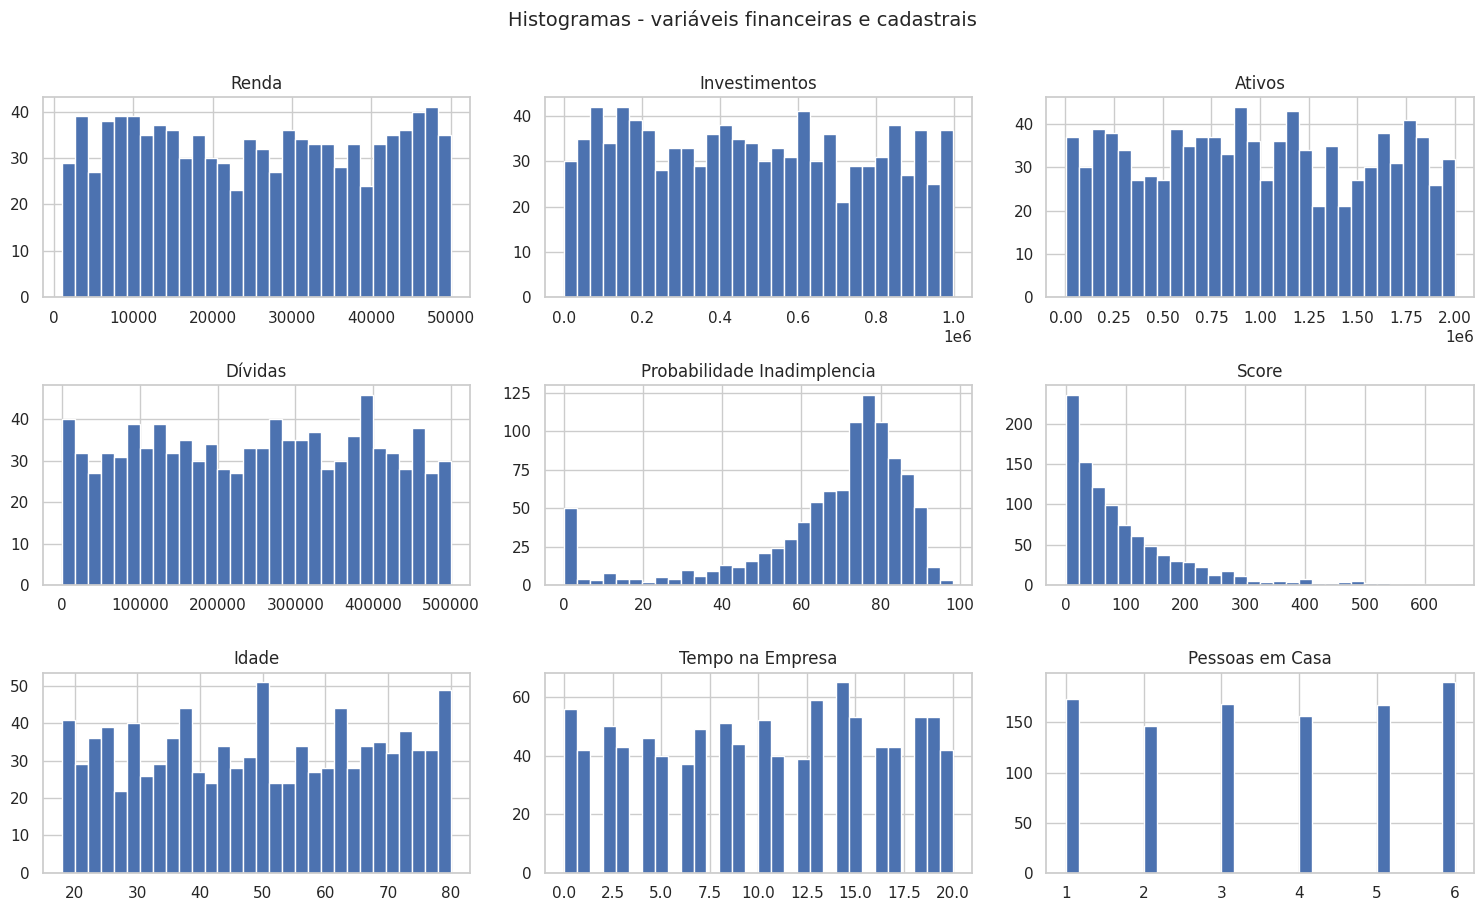

In [6]:
COLUNAS_FINANCEIRAS = ["Renda", "Investimentos", "Ativos", "Dívidas",
                       "Probabilidade Inadimplencia", "Score"]
COLUNAS_PREFERENCIA = ["Viagens", "Restaurantes", "Entretenimento", "Cashback",
                       "Compras online", "Farmácias", "Programas de Milhagem",
                       "Postos de Combustível", "Mercados"]
COLUNAS_CADASTRAIS = ["Idade", "Tempo na Empresa", "Pessoas em Casa"]

df[COLUNAS_FINANCEIRAS + COLUNAS_CADASTRAIS].hist(figsize=(15, 9), bins=30, edgecolor="white")
plt.suptitle("Histogramas - variáveis financeiras e cadastrais", y=1.01, fontsize=14)
plt.tight_layout()
plt.show()

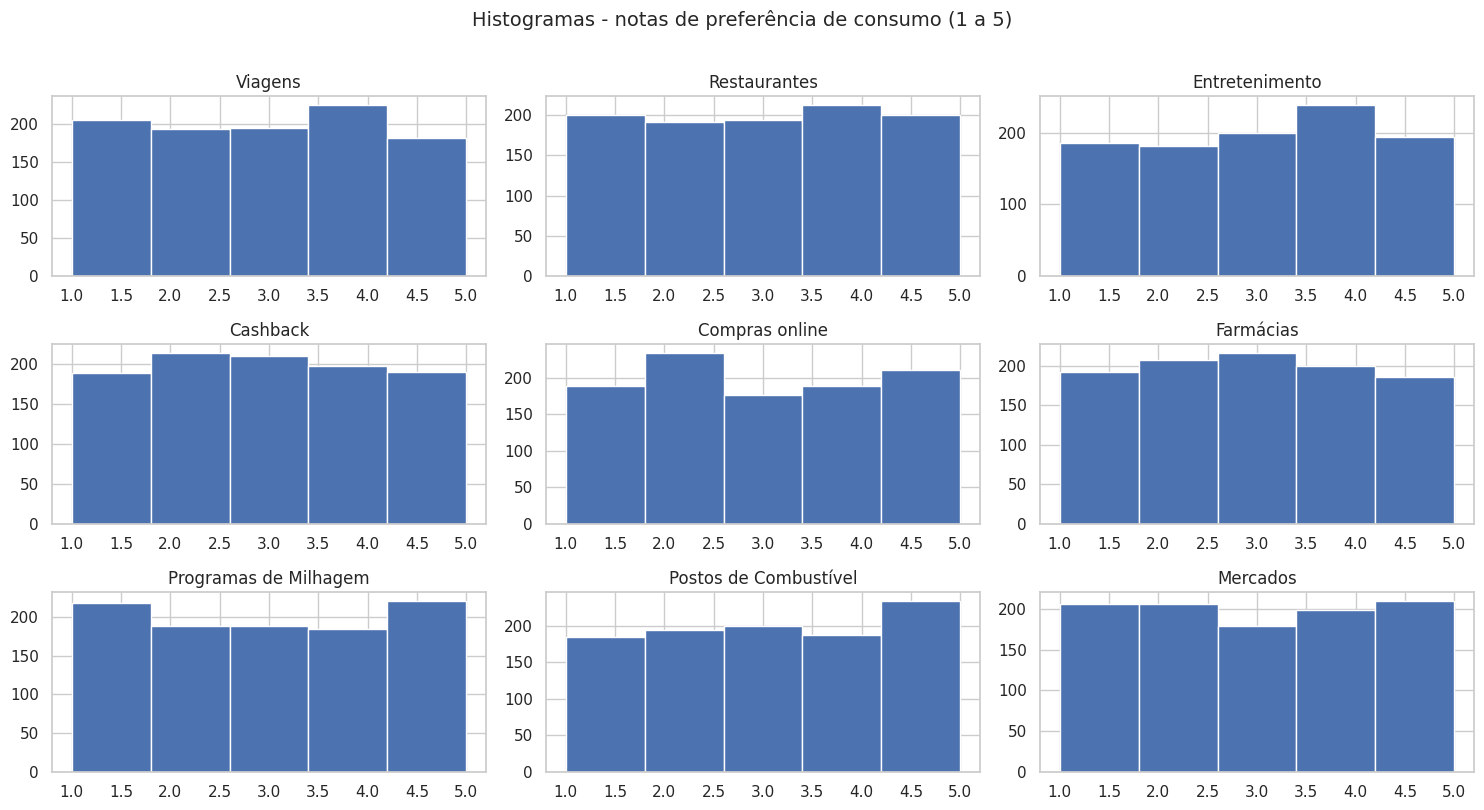

In [7]:
df[COLUNAS_PREFERENCIA].hist(figsize=(15, 8), bins=5, edgecolor="white")
plt.suptitle("Histogramas - notas de preferência de consumo (1 a 5)", y=1.01, fontsize=14)
plt.tight_layout()
plt.show()

Chama atenção que `Investimentos`, `Ativos` e `Dívidas` são praticamente uniformes —
não têm o formato assimétrico que a gente costuma ver em valores financeiros. Já `Score`
é bem concentrado em valores baixos, com uma cauda longa. As notas de preferência estão
distribuídas de forma bastante equilibrada entre 1 e 5.

### 1.2 Matriz de correlação

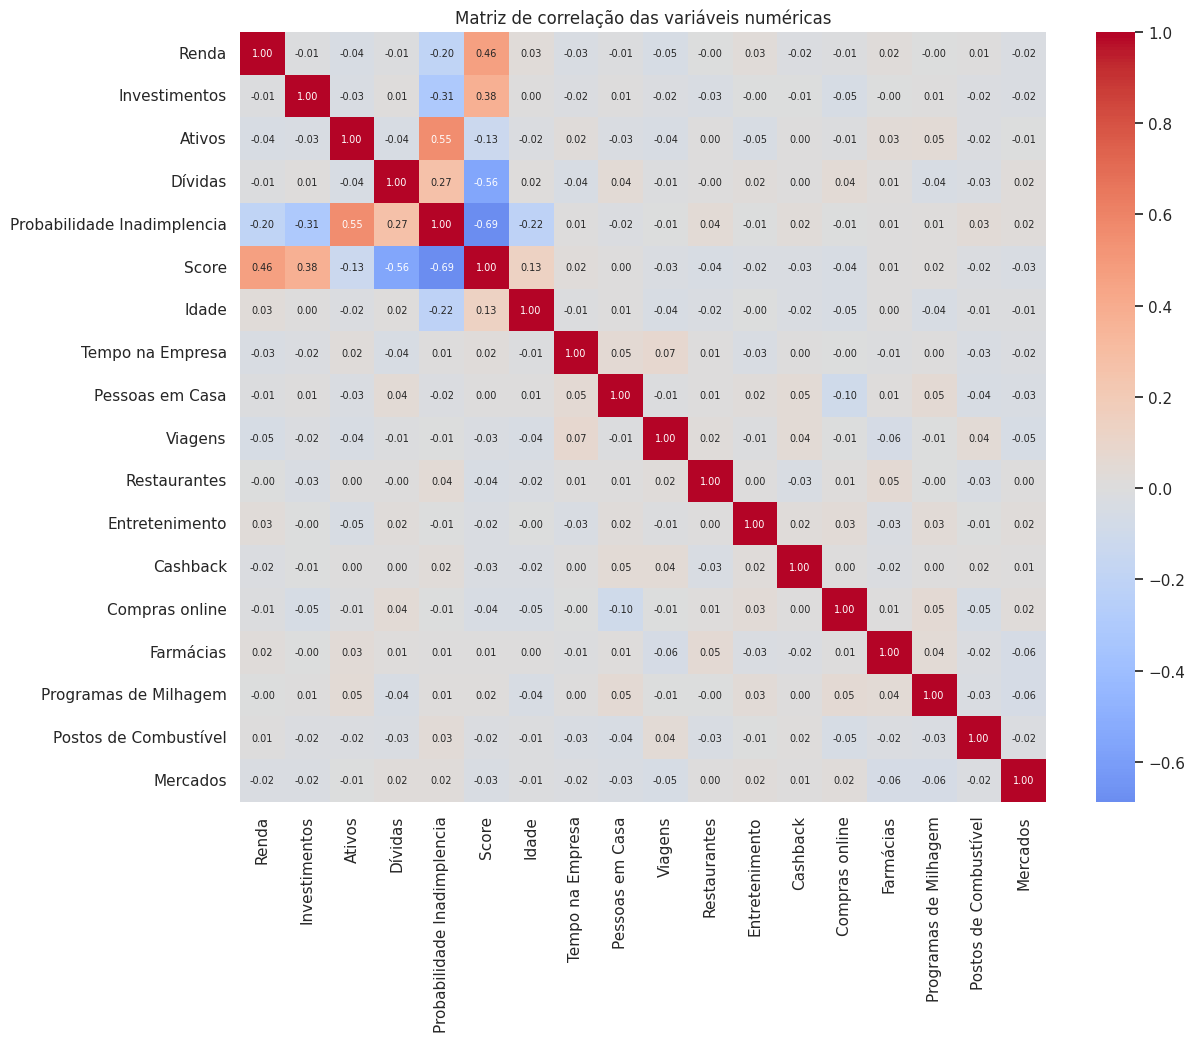

In [8]:
colunas_numericas = COLUNAS_FINANCEIRAS + COLUNAS_CADASTRAIS + COLUNAS_PREFERENCIA
matriz_corr = df[colunas_numericas].corr()

plt.figure(figsize=(13, 10))
sns.heatmap(matriz_corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            annot_kws={"size": 7})
plt.title("Matriz de correlação das variáveis numéricas")
plt.show()

In [9]:
corr_com_renda = matriz_corr["Renda"].drop("Renda").sort_values(key=abs, ascending=False)
print("Correlação com a Renda:")
print(corr_com_renda.round(3))

Correlação com a Renda:
Score                          0.464
Probabilidade Inadimplencia   -0.196
Viagens                       -0.052
Ativos                        -0.039
Tempo na Empresa              -0.030
Idade                          0.027
Entretenimento                 0.025
Mercados                      -0.022
Farmácias                      0.020
Cashback                      -0.016
Compras online                -0.011
Investimentos                 -0.011
Dívidas                       -0.010
Pessoas em Casa               -0.010
Postos de Combustível          0.008
Programas de Milhagem         -0.005
Restaurantes                  -0.004
Name: Renda, dtype: float64


Aqui está o principal problema do dataset: **só o `Score` tem correlação relevante com a
renda (0,46)**. Todo o resto fica perto de zero. Isso já indica que uma regressão linear
simples, com as variáveis do jeito que elas vêm, não vai chegar muito longe.

Reparei também numa pista importante: `Score` se correlaciona forte com
`Probabilidade Inadimplencia` (-0,69) e com `Dívidas` (-0,56). Ou seja, o score parece ser
uma nota calculada em cima do conjunto financeiro do cliente, e não uma variável independente.
Vou usar isso na modelagem.

### 1.3 ANOVA das variáveis categóricas

In [10]:
COLUNAS_CATEGORICAS = ["Cidade", "Estado Civil", "Moradia"]

for coluna in COLUNAS_CATEGORICAS:
    grupos = [grupo["Renda"].values for _, grupo in df.groupby(coluna)]
    estatistica_f, p_valor = f_oneway(*grupos)
    resultado = "significativo" if p_valor < 0.05 else "não significativo"
    print(f"{coluna:<15} F = {estatistica_f:6.2f}   p-valor = {p_valor:.4f}   ({resultado})")

# Possui Carro é booleano, então comparo só os dois grupos
grupo_com_carro = df.loc[df["Possui Carro"], "Renda"].values
grupo_sem_carro = df.loc[~df["Possui Carro"], "Renda"].values
estatistica_f, p_valor = f_oneway(grupo_com_carro, grupo_sem_carro)
print(f"{'Possui Carro':<15} F = {estatistica_f:6.2f}   p-valor = {p_valor:.4f}   "
      f"({'significativo' if p_valor < 0.05 else 'não significativo'})")

Cidade          F =   1.17   p-valor = 0.2934   (não significativo)
Estado Civil    F =   0.99   p-valor = 0.3973   (não significativo)
Moradia         F =   1.50   p-valor = 0.2204   (não significativo)
Possui Carro    F =   0.48   p-valor = 0.4899   (não significativo)


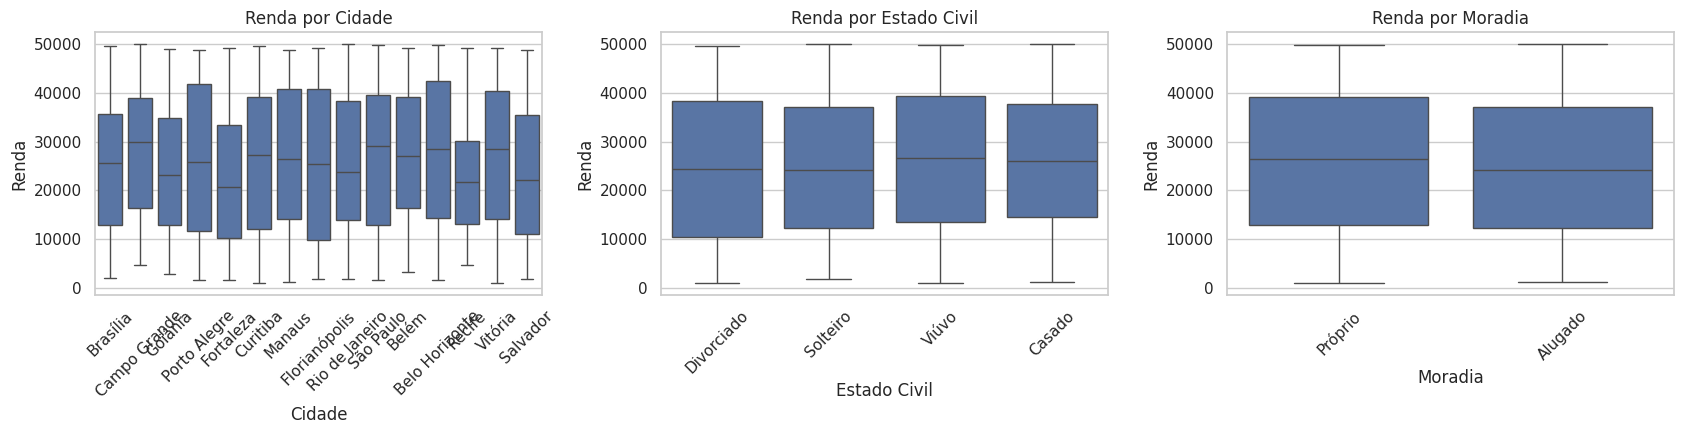

In [11]:
fig, eixos = plt.subplots(1, 3, figsize=(17, 4.5))
for eixo, coluna in zip(eixos, COLUNAS_CATEGORICAS):
    sns.boxplot(data=df, x=coluna, y="Renda", ax=eixo)
    eixo.set_title(f"Renda por {coluna}")
    eixo.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

A ANOVA confirma o que os boxplots mostram: nenhuma variável categórica separa a renda de
forma significativa (todos os p-valores acima de 0,05). Vou manter elas no modelo mesmo assim,
já que não atrapalham, mas não espero contribuição relevante delas.

## 2. Pré-processamento

Colunas descartadas: `ID_Cliente` e `Nome` (identificadores), `Cargo` (alta cardinalidade,
viraria centenas de dummies para 1000 linhas) e `Principal Cartão` (base da target do Desafio 2).

Sobre o encoding: o `OneHotEncoder` é ajustado **dentro do Pipeline**, ou seja, só aprende as
categorias a partir do treino. Isso evita vazamento de dados para o teste.

In [12]:
COLUNAS_DESCARTADAS = ["ID_Cliente", "Nome", "Cargo", "Principal Cartão"]

X = df.drop(columns=COLUNAS_DESCARTADAS + ["Renda"]).copy()
X["Possui Carro"] = X["Possui Carro"].astype(int)  # bool vira 0/1
y = df["Renda"]

print("Features:", X.shape[1])
print("Categóricas:", COLUNAS_CATEGORICAS)

Features: 21
Categóricas: ['Cidade', 'Estado Civil', 'Moradia']


In [13]:
X_treino, X_teste, y_treino, y_teste = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)
print("Treino:", X_treino.shape, "| Teste:", X_teste.shape)

Treino: (800, 21) | Teste: (200, 21)


## 3. Modelagem

### 3.1 Primeira tentativa: regressão linear simples

Comecei pelo modelo mais direto, só com One-Hot nas categóricas e as numéricas cruas.

In [14]:
preprocessador_simples = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(drop="first", sparse_output=False), COLUNAS_CATEGORICAS),
    ],
    remainder="passthrough",
)

modelo_simples = Pipeline(steps=[
    ("preprocessador", preprocessador_simples),
    ("regressor", LinearRegression()),
])

modelo_simples.fit(X_treino, y_treino)
r2_simples = modelo_simples.score(X_teste, y_teste)
print(f"R² no teste (modelo simples): {r2_simples:.4f}")

R² no teste (modelo simples): 0.4716


R² de aproximadamente 0,47 — bem abaixo da meta de referência de 0,70. Era o esperado, porque
nenhuma variável tem relação linear forte com a renda.

### 3.2 Segunda tentativa: termos polinomiais nas variáveis financeiras

Como observei na correlação, o `Score` parece ser uma nota derivada do conjunto financeiro
(renda, dívidas, investimentos, inadimplência). Se é assim, a relação entre essas variáveis e a
renda envolve **interações** entre elas, não uma soma simples.

Então apliquei `PolynomialFeatures(degree=2)` só nas 5 variáveis financeiras, o que gera os
quadrados e todos os produtos cruzados entre elas. O modelo continua sendo uma
`LinearRegression` — o que muda é o conjunto de features que entra nela.

In [15]:
FEATURES_POLINOMIAIS = ["Investimentos", "Ativos", "Dívidas",
                        "Probabilidade Inadimplencia", "Score"]

preprocessador = ColumnTransformer(
    transformers=[
        ("poly", PolynomialFeatures(degree=2, include_bias=False), FEATURES_POLINOMIAIS),
        ("cat", OneHotEncoder(drop="first", sparse_output=False), COLUNAS_CATEGORICAS),
    ],
    remainder="passthrough",
)

modelo_renda = Pipeline(steps=[
    ("preprocessador", preprocessador),
    ("regressor", LinearRegression()),
])

modelo_renda.fit(X_treino, y_treino)
print("Total de features geradas:",
      len(modelo_renda.named_steps["preprocessador"].get_feature_names_out()))

Total de features geradas: 51


## 4. Avaliação

In [16]:
def avaliar_regressao(y_verdadeiro, y_predito, titulo="Resultados"):
    """Calcula RMSE, MAE e R² e devolve os valores em um dicionário."""
    rmse = np.sqrt(mean_squared_error(y_verdadeiro, y_predito))
    mae = mean_absolute_error(y_verdadeiro, y_predito)
    r2 = r2_score(y_verdadeiro, y_predito)

    print(f"--- {titulo} ---")
    print(f"RMSE : R$ {rmse:,.2f}")
    print(f"MAE  : R$ {mae:,.2f}")
    print(f"R²   : {r2:.4f}")
    return {"rmse": rmse, "mae": mae, "r2": r2}


y_predito = modelo_renda.predict(X_teste)
metricas_teste = avaliar_regressao(y_teste, y_predito, "Conjunto de teste")

print(f"\nGanho em relação ao modelo simples: {metricas_teste['r2'] - r2_simples:+.4f} de R²")

--- Conjunto de teste ---
RMSE : R$ 5,554.25
MAE  : R$ 4,249.58
R²   : 0.8582

Ganho em relação ao modelo simples: +0.3866 de R²


### 4.1 Validação cruzada (5 folds)

In [17]:
scores_cv = cross_val_score(modelo_renda, X, y, cv=5, scoring="r2")

print("R² por fold:", np.round(scores_cv, 4))
print(f"R² médio   : {scores_cv.mean():.4f} (desvio padrão {scores_cv.std():.4f})")

R² por fold: [0.8467 0.7764 0.8336 0.8196 0.8502]
R² médio   : 0.8253 (desvio padrão 0.0267)


O R² médio da validação cruzada ficou um pouco abaixo do R² do teste, mas próximo, e o
desvio padrão entre os folds é pequeno. Isso indica que o ganho dos termos polinomiais é real
e não foi sorte da divisão treino/teste.

### 4.2 Análise de resíduos

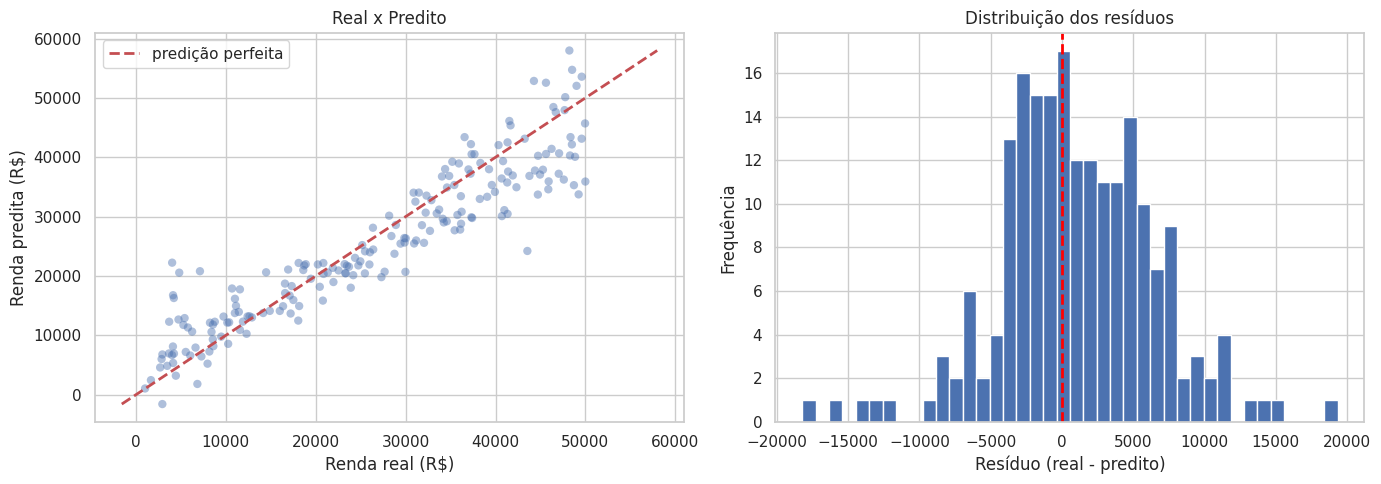

Média dos resíduos: 1,006.68
Desvio padrão     : 5,475.97


In [18]:
residuos = y_teste - y_predito

fig, eixos = plt.subplots(1, 2, figsize=(14, 5))

eixos[0].scatter(y_teste, y_predito, alpha=0.45, edgecolor="none")
limites = [min(y_teste.min(), y_predito.min()), max(y_teste.max(), y_predito.max())]
eixos[0].plot(limites, limites, "r--", linewidth=2, label="predição perfeita")
eixos[0].set_xlabel("Renda real (R$)")
eixos[0].set_ylabel("Renda predita (R$)")
eixos[0].set_title("Real x Predito")
eixos[0].legend()

eixos[1].hist(residuos, bins=40, edgecolor="white")
eixos[1].axvline(0, color="red", linestyle="--", linewidth=2)
eixos[1].set_xlabel("Resíduo (real - predito)")
eixos[1].set_ylabel("Frequência")
eixos[1].set_title("Distribuição dos resíduos")

plt.tight_layout()
plt.show()

print(f"Média dos resíduos: {residuos.mean():,.2f}")
print(f"Desvio padrão     : {residuos.std():,.2f}")

Os pontos acompanham bem a diagonal e os resíduos ficam centrados perto de zero, com
formato aproximadamente simétrico. Dá para notar que os erros maiores se concentram nas rendas
mais baixas, onde o modelo tende a superestimar um pouco.

### 4.3 Coeficientes do modelo

In [19]:
nomes_features = modelo_renda.named_steps["preprocessador"].get_feature_names_out()
coeficientes = modelo_renda.named_steps["regressor"].coef_

tabela_coeficientes = (
    pd.DataFrame({"feature": nomes_features, "coeficiente": coeficientes})
    .assign(magnitude=lambda t: t["coeficiente"].abs())
    .sort_values("magnitude", ascending=False)
    .reset_index(drop=True)
)

print(f"Intercepto: {modelo_renda.named_steps['regressor'].intercept_:,.2f}\n")
tabela_coeficientes.head(15)

Intercepto: 5,504.72



,feature,coeficiente,magnitude
0,cat__Estado Civil_Solteiro,-1143.715639,1143.715639
1,cat__Cidade_Porto Alegre,1026.445572,1026.445572
2,cat__Cidade_Recife,-896.979958,896.979958
3,cat__Cidade_Campo Grande,839.829507,839.829507
4,cat__Estado Civil_Viúvo,-788.026885,788.026885
5,cat__Cidade_São Paulo,-749.238516,749.238516
6,cat__Estado Civil_Divorciado,-697.828264,697.828264
7,cat__Cidade_Curitiba,-448.370931,448.370931
8,cat__Cidade_Goiânia,-422.210219,422.210219
9,cat__Cidade_Vitória,411.777052,411.777052


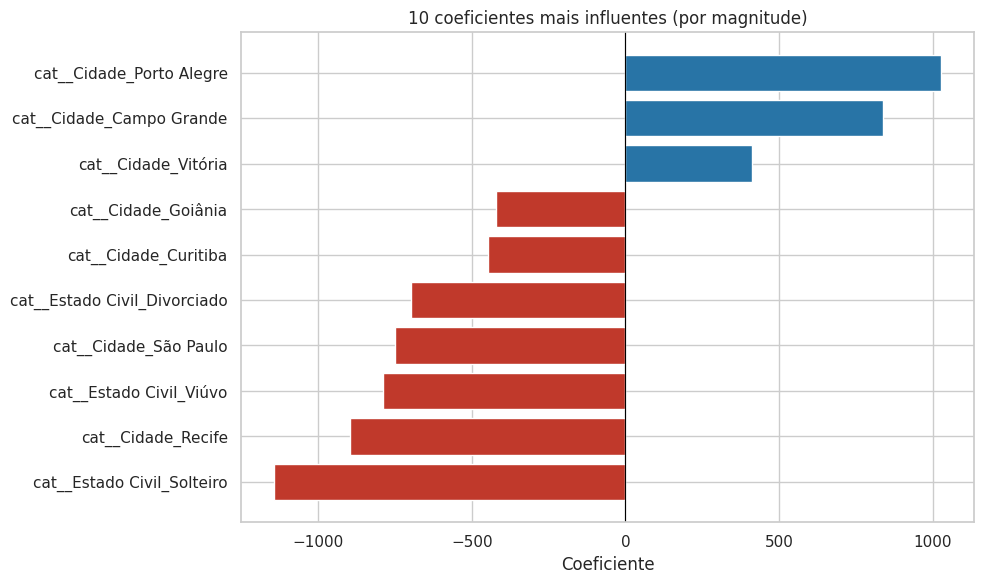

In [20]:
plt.figure(figsize=(10, 6))
tabela_top = tabela_coeficientes.head(10).sort_values("coeficiente")
cores = ["#c0392b" if valor < 0 else "#2874a6" for valor in tabela_top["coeficiente"]]
plt.barh(tabela_top["feature"], tabela_top["coeficiente"], color=cores)
plt.axvline(0, color="black", linewidth=0.8)
plt.title("10 coeficientes mais influentes (por magnitude)")
plt.xlabel("Coeficiente")
plt.tight_layout()
plt.show()

Importante ler essa tabela com cuidado: as variáveis estão em escalas muito diferentes
(Ativos chega a 2 milhões, Score fica abaixo de 700), então comparar a magnitude bruta dos
coeficientes não é uma comparação justa de importância. O que dá para afirmar com segurança é
que os termos que envolvem `Score` aparecem no topo, o que bate com a análise de correlação.

## 5. Salvando o modelo

In [21]:
joblib.dump(modelo_renda, "modelo_renda.pkl")
print("Modelo salvo em modelo_renda.pkl")

modelo_carregado = joblib.load("modelo_renda.pkl")
print("Predição do 1º cliente do teste:",
      f"R$ {modelo_carregado.predict(X_teste.head(1))[0]:,.2f}",
      "| valor real:", f"R$ {y_teste.iloc[0]:,.2f}")

Modelo salvo em modelo_renda.pkl
Predição do 1º cliente do teste: R$ 33,342.57 | valor real: R$ 39,074.00


## 6. Conclusões

**Resultados no conjunto de teste**

| Modelo | R² | RMSE | MAE |
|---|---|---|---|
| Regressão linear simples | ~ 0,47 | — | — |
| Regressão linear com termos polinomiais | ~ 0,86 | ~ R$ 5.550 | ~ R$ 4.250 |
| Validação cruzada 5 folds (modelo final) | ~ 0,83 | | |

*(os valores exatos estão impressos nas células acima)*

**Interpretação**

- O modelo final explica cerca de 86% da variação da renda, acima da meta de referência
  de 0,70. Mas o caminho até aí foi menos direto do que eu esperava.
- Com as variáveis cruas, a regressão linear ficou em R² de aproximadamente 0,47. O motivo
  aparece na matriz de correlação: só o `Score` tem relação linear relevante com a renda
  (0,46), e todas as outras variáveis ficam praticamente em zero.
- O salto veio de aplicar `PolynomialFeatures(degree=2)` nas 5 variáveis financeiras. Isso
  faz sentido pela leitura dos dados: o `Score` se comporta como uma nota calculada em cima de
  renda, dívidas, investimentos e inadimplência ao mesmo tempo. A relação entre esse conjunto e
  a renda passa por interações entre as variáveis, e não por uma soma simples — é exatamente
  isso que os produtos cruzados capturam.
- O RMSE de aproximadamente R$ 5.550 parece alto em valor absoluto, mas a renda nessa base vai
  de R$ 1.000 a quase R$ 50.000, com média em torno de R$ 25.500. Proporcionalmente, o erro
  fica em torno de 20% da renda média.
- O MAE ficou bem abaixo do RMSE, o que indica que existem alguns erros grandes puxando o RMSE
  para cima — provavelmente os clientes de renda muito baixa, onde o modelo superestima.
- As variáveis categóricas (`Cidade`, `Estado Civil`, `Moradia`) não passaram na ANOVA e
  praticamente não contribuíram. Numa próxima versão dava para removê-las e simplificar o modelo.

**O que dá para melhorar**

Com tantos termos polinomiais (mais de 50 features para 800 linhas de treino), o risco de
overfitting cresce. Um `Ridge` ou `Lasso` provavelmente daria um resultado parecido com mais
estabilidade, e o Lasso ainda ajudaria a selecionar quais interações realmente importam.
Também vale testar transformação logarítmica na target, já que os maiores erros estão
concentrados na faixa de renda mais baixa.